# Unemployment Analysis Using Python

This comprehensive analysis explores unemployment trends across Indian states and regions. The dataset contains monthly unemployment statistics from 2019 to 2020, including regional employment data, labor force participation rates, and employment numbers. We'll use exploratory data analysis, visualization, and statistical aggregation to uncover patterns and insights.

## Step 1: Import Required Libraries

We begin by importing essential Python libraries for data manipulation, visualization, and analysis:

- **pandas**: For loading, cleaning, and manipulating structured data in dataframe format
- **matplotlib**: For creating static, high-quality visualizations and plots
- **plotly**: For interactive, web-based visualizations that enable hover details and zooming
- **seaborn**: For statistical data visualization built on top of matplotlib with enhanced aesthetics
- **numpy**: For numerical computations and array operations
- **%matplotlib inline**: Jupyter magic command to display plots directly in notebook cells

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.figure_factory as ff

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import IFrame
import seaborn as sns
import numpy as np

%matplotlib inline


## Step 2: Load and Explore Datasets

We load two unemployment datasets from Kaggle:

1. **Main Dataset (df)**: Contains unemployment data spanning 2019-2020 with monthly frequency. Includes regional unemployment rates, employment estimates, labor participation rates, and geographic classification (Rural/Urban).

2. **2020 Dataset (df_2020)**: Supplementary data covering unemployment rates up to November 2020. This dataset includes geographic coordinates (longitude/latitude) and regional classification by geographical area (North, South, East, West).

After loading, we display the first 5 rows to understand the structure and data types.

In [2]:
df = pd.read_csv("Unemployment in India.csv")
df_2020 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [3]:
df.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


In [4]:
df_2020.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74
5,Andhra Pradesh,30-06-2020,M,3.31,19805400,47.41,South,15.9129,79.74
6,Andhra Pradesh,31-07-2020,M,8.34,15431615,38.91,South,15.9129,79.74
7,Andhra Pradesh,31-08-2020,M,6.96,15251776,37.83,South,15.9129,79.74
8,Andhra Pradesh,30-09-2020,M,6.40,15220312,37.47,South,15.9129,79.74
9,Andhra Pradesh,31-10-2020,M,6.59,15157557,37.34,South,15.9129,79.74


## Step 3: Dataset Information and Structure

We examine the shape and data types of both datasets to understand their dimensions and structure:

- **df.info()**: Provides column names, data types, and non-null counts for the main dataset
- **df_2020.info()**: Same information for the 2020 supplementary dataset
- **df.describe()**: Statistical summary (count, mean, std, min, 25%, 50%, 75%, max) for numerical columns
- **df_2020.describe()**: Statistical summary for the 2020 dataset
- **df.shape** and **df_2020.shape**: Show dimensions (rows, columns) of each dataset

In [5]:
df.info()
print("\n" + "="*80 + "\n")
df_2020.info()
print("\n" + "="*80 + "\n")
print(df.describe())
print("\n" + "="*80 + "\n")
print(df_2020.describe())
print("\n" + "="*80 + "\n")
print(f"Main dataset shape: {df.shape}")
print(f"2020 dataset shape: {df_2020.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                

## Step 4: Data Cleaning and Preprocessing

This step prepares the data for analysis through multiple transformations:

1. **Convert date strings to datetime objects**: The 'Date' column is converted from string format (DD-MM-YYYY) to pandas datetime type, enabling temporal analysis and sorting.

2. **Extract month information**: We create two new columns:
   - **Month_int**: Numeric month value (1-12) extracted from the date for aggregation and ordering
   - **Month**: Month name (e.g., 'January', 'February') for readable visualizations

3. **Drop redundant columns**: Remove columns that don't add analytical value (Frequency column indicates all entries are monthly, so it's redundant)

4. **Data validation**: Display the cleaned dataframe structure to confirm transformations succeeded

In [6]:
df.columns = df.columns.str.strip()
df_2020.columns = df_2020.columns.str.strip()

In [7]:
df['Date'] = df['Date'].astype(str).str.strip()
df_2020['Date'] = df_2020['Date'].astype(str).str.strip()

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df_2020['Date'] = pd.to_datetime(df_2020['Date'], format='%d-%m-%Y', errors='coerce')

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Month_int'] = df['Date'].dt.month
df['Month'] = df['Date'].dt.strftime('%B')
df = df.drop('Frequency', axis=1)

df_2020['Date'] = pd.to_datetime(df_2020['Date'], format='%d-%m-%Y')
df_2020['Month_int'] = df_2020['Date'].dt.month
df_2020['Month'] = df_2020['Date'].dt.strftime('%B')
df_2020 = df_2020.drop(['Frequency', 'Region.1', 'longitude', 'latitude'], axis=1)

print("Cleaned main dataset:")
print(df.head())
print("\n" + "="*80 + "\n")
print("Cleaned 2020 dataset:")
print(df_2020.head())

Cleaned main dataset:
           Region       Date  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31                             3.65   
1  Andhra Pradesh 2019-06-30                             3.05   
2  Andhra Pradesh 2019-07-31                             3.75   
3  Andhra Pradesh 2019-08-31                             3.32   
4  Andhra Pradesh 2019-09-30                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  \
0          11999139.0                                    43.24  Rural   
1          11755881.0                                    42.05  Rural   
2          12086707.0                                    43.50  Rural   
3          12285693.0                                    43.97  Rural   
4          12256762.0                                    44.68  Rural   

   Month_int      Month  
0        5.0        May  
1        6.0       June  
2        7.0       July  
3        8.0     August  
4        9.0  Sept

## Step 5: Combine Datasets for Comprehensive Analysis

We merge the main dataset with the 2020 supplementary data using pandas concatenation:

- **pd.concat()**: Combines two dataframes vertically (row-wise)
- **ignore_index=True**: Resets the row indices to create a continuous range from 0 to total rows

This creates a unified dataset containing all unemployment records from both time periods. We then verify the combined dataset's shape and display sample records.

In [9]:
combined_df = pd.concat([df, df_2020], ignore_index=True)
print(f"Combined dataset shape: {combined_df.shape}")
print(combined_df.head())
print("\n" + "="*80 + "\n")
print(combined_df.tail())

Combined dataset shape: (1035, 8)
           Region       Date  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31                             3.65   
1  Andhra Pradesh 2019-06-30                             3.05   
2  Andhra Pradesh 2019-07-31                             3.75   
3  Andhra Pradesh 2019-08-31                             3.32   
4  Andhra Pradesh 2019-09-30                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  \
0          11999139.0                                    43.24  Rural   
1          11755881.0                                    42.05  Rural   
2          12086707.0                                    43.50  Rural   
3          12285693.0                                    43.97  Rural   
4          12256762.0                                    44.68  Rural   

   Month_int      Month  
0        5.0        May  
1        6.0       June  
2        7.0       July  
3        8.0     August  
4     

## Step 6: Aggregating Unemployment Data by Region

We perform aggregation operations to summarize unemployment metrics at the regional level:

- **groupby('Region')**: Groups all records by state/region
- **agg()**: Applies multiple aggregation functions simultaneously:
  - **sum()**: Total unemployment across all time periods (cumulative measure)
  - **mean()**: Average unemployment rate per region (central tendency)
  - **min()**: Minimum recorded unemployment in each region (best-case scenario)
  - **max()**: Maximum recorded unemployment in each region (worst-case scenario)

This helps identify which regions experienced the most severe unemployment issues and their variation over time.

In [10]:
unemployment_by_region_sum = combined_df.groupby('Region')['Estimated Unemployment Rate (%)'].sum().sort_values(ascending=False)
unemployment_by_region_mean = combined_df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
unemployment_by_region_min = combined_df.groupby('Region')['Estimated Unemployment Rate (%)'].min()
unemployment_by_region_max = combined_df.groupby('Region')['Estimated Unemployment Rate (%)'].max()

print("Total unemployment by region (sum):")
print(unemployment_by_region_sum)
print("\n" + "="*80 + "\n")
print("Average unemployment by region (mean):")
print(unemployment_by_region_mean)

Total unemployment by region (sum):
Region
Tripura             1044.36
Haryana             1010.70
Jharkhand            771.77
Bihar                724.42
Himachal Pradesh     679.78
Delhi                646.01
Rajasthan            552.31
Jammu & Kashmir      488.26
Punjab               456.68
Uttar Pradesh        448.81
Puducherry           445.01
Tamil Nadu           381.83
Kerala               377.81
Goa                  344.25
Chhattisgarh         336.92
West Bengal          329.41
Andhra Pradesh       296.00
Maharashtra          291.40
Uttarakhand          289.30
Telangana            284.99
Madhya Pradesh       275.92
Karnataka            263.61
Gujarat              250.35
Odisha               223.04
Assam                215.69
Sikkim               201.58
Chandigarh           191.90
Meghalaya            168.23
Name: Estimated Unemployment Rate (%), dtype: float64


Average unemployment by region (mean):
Region
Tripura             27.483158
Haryana             26.597368
Jharkhand  

## Step 7: Aggregating Unemployment Data by Month

We analyze temporal patterns by aggregating unemployment metrics across different months:

- **groupby('Month')**: Groups records by month name
- **agg()**: Applies aggregation functions to identify:
  - **sum()**: Cumulative unemployment across all regions for each month
  - **mean()**: Average unemployment rate for each month

This reveals seasonal patterns and identifies which months typically experience higher or lower unemployment rates across the entire country.

In [11]:
unemployment_by_month_sum = combined_df.groupby('Month')['Estimated Unemployment Rate (%)'].sum().sort_values(ascending=False)
unemployment_by_month_mean = combined_df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print("Total unemployment by month (sum):")
print(unemployment_by_month_sum)
print("\n" + "="*80 + "\n")
print("Average unemployment by month (mean):")
print(unemployment_by_month_mean)

Total unemployment by month (sum):
Month
May          2375.45
April        1783.86
June         1392.16
March         847.56
August        789.27
February      769.05
January       766.50
October       761.26
July          753.36
September     705.75
November      542.76
December      503.36
Name: Estimated Unemployment Rate (%), dtype: float64


Average unemployment by month (mean):
Month
April        23.167013
May          17.995833
March        10.728608
June         10.627176
November      9.868364
August        9.865875
February      9.734810
January       9.702532
December      9.497358
July          9.300741
October       9.283659
September     8.933544
Name: Estimated Unemployment Rate (%), dtype: float64


## Step 8: Employment Analysis by Region

We examine employment patterns across regions using aggregation functions:

- **sum()**: Total employment count across all months for each region
- **mean()**: Average employment level per region

This identifies which regions have the largest labor forces and helps correlate employment levels with unemployment rates. High employment doesn't necessarily mean low unemployment, as labor force participation varies by region.

In [12]:
employed_by_region_sum = combined_df.groupby('Region')['Estimated Employed'].sum().sort_values(ascending=False)
employed_by_region_mean = combined_df.groupby('Region')['Estimated Employed'].mean().sort_values(ascending=False)

print("Total employment by region (sum):")
print(employed_by_region_sum)
print("\n" + "="*80 + "\n")
print("Average employment by region (mean):")
print(employed_by_region_mean)

Total employment by region (sum):
Region
Uttar Pradesh       1.341903e+09
Maharashtra         9.517731e+08
West Bengal         8.146107e+08
Bihar               5.823216e+08
Tamil Nadu          5.634263e+08
Gujarat             5.465638e+08
Madhya Pradesh      5.344169e+08
Karnataka           5.149195e+08
Rajasthan           4.784673e+08
Telangana           3.847514e+08
Andhra Pradesh      3.825694e+08
Odisha              3.105492e+08
Assam               2.473268e+08
Punjab              2.149325e+08
Jharkhand           2.128452e+08
Kerala              2.098931e+08
Chhattisgarh        2.047115e+08
Haryana             1.680386e+08
Delhi               1.198986e+08
Jammu & Kashmir     6.758885e+07
Uttarakhand         6.496891e+07
Himachal Pradesh    5.001391e+07
Tripura             3.404899e+07
Meghalaya           3.212105e+07
Goa                 9.855148e+06
Puducherry          9.171859e+06
Chandigarh          3.801975e+06
Sikkim              3.693158e+06
Name: Estimated Employed, dtype: fl

## Step 9: Aggregating Employment by Month

We analyze monthly employment trends using time-based aggregation:

- **groupby('Month')**: Groups employment records by month
- **sum()**: Cumulative employment across all regions for each month
- **mean()**: Average employment level per month

This reveals whether employment varies seasonally and identifies months with stronger or weaker labor markets.

In [13]:
employed_by_month_sum = combined_df.groupby('Month')['Estimated Employed'].sum().sort_values(ascending=False)
employed_by_month_mean = combined_df.groupby('Month')['Estimated Employed'].mean().sort_values(ascending=False)

print("Total employment by month (sum):")
print(employed_by_month_sum)
print("\n" + "="*80 + "\n")
print("Average employment by month (mean):")
print(employed_by_month_mean)

Total employment by month (sum):
Month
June         1.140867e+09
May          1.010695e+09
January      8.134664e+08
February     8.057067e+08
September    7.963238e+08
October      7.950705e+08
August       7.891943e+08
July         7.891255e+08
March        7.834060e+08
April        5.442745e+08
November     4.000513e+08
December     3.910016e+08
Name: Estimated Employed, dtype: float64


Average employment by month (mean):
Month
January      1.029704e+07
February     1.019882e+07
September    1.008005e+07
March        9.916532e+06
August       9.864929e+06
July         9.742291e+06
October      9.695982e+06
June         8.708906e+06
May          7.656782e+06
December     7.377388e+06
November     7.273661e+06
April        7.068500e+06
Name: Estimated Employed, dtype: float64


## Step 10: Create Interactive Visualizations with Plotly

We create professional, interactive visualizations that allow users to explore data dynamically:

### Unemployment by Region (Bar Chart)
- Uses top 10 regions ranked by total unemployment
- **plotly.express.bar()**: Creates interactive bar charts with hover information
- Color gradient from light to dark indicates magnitude of values
- Interactive features: hover for exact values, click legend to toggle visibility, zoom/pan capabilities

### Unemployment by Month (Bar Chart)
- Displays seasonal unemployment patterns across all months
- Enables identification of high-unemployment months (e.g., April-June 2020 showed COVID-19 impact)

### Employment by Region (Bar Chart)
- Shows regional employment distribution
- Identifies regions with largest labor forces

### Employment by Month (Bar Chart)
- Reveals temporal employment fluctuations
- Helps correlate with unemployment trends

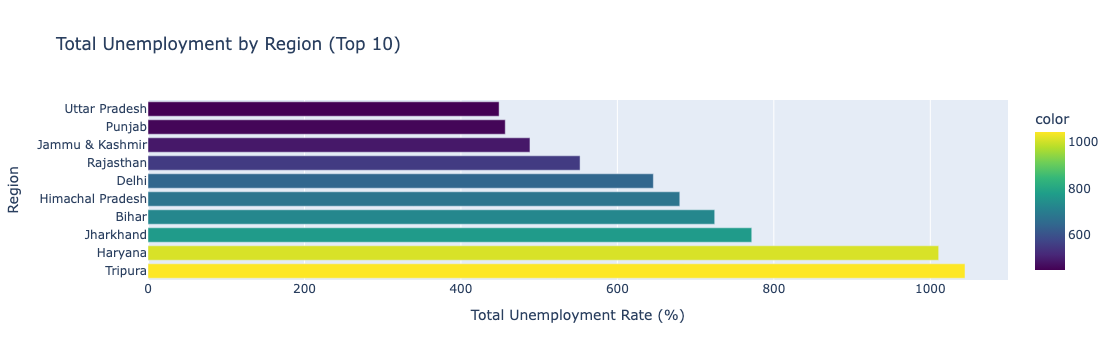

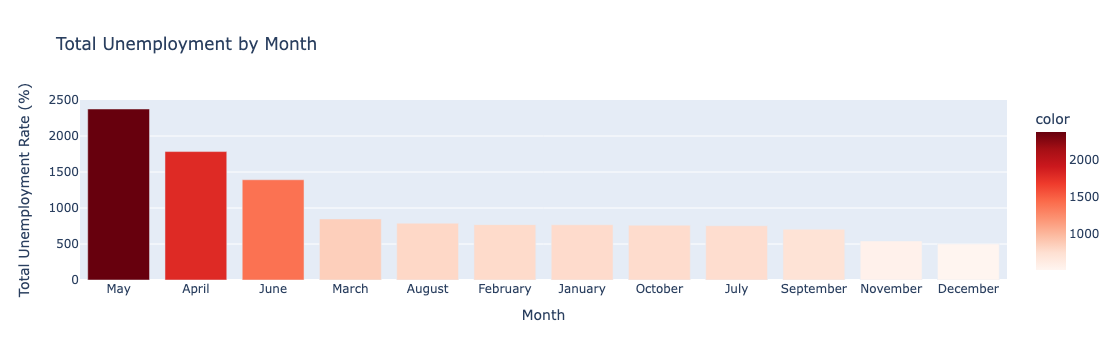

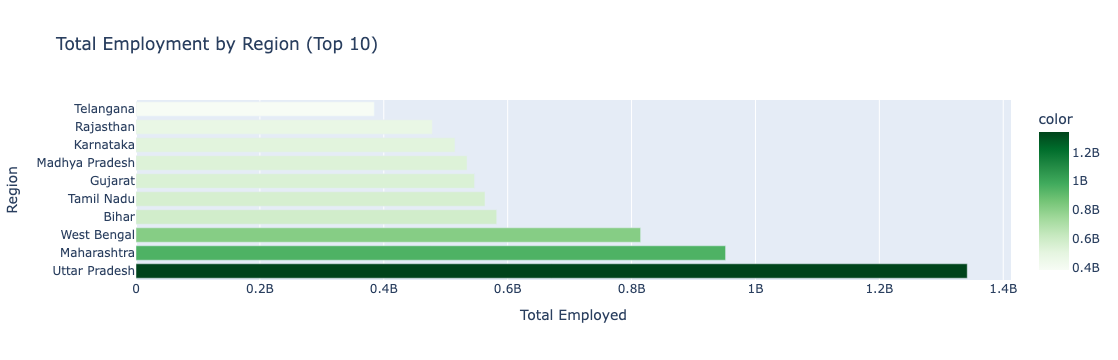

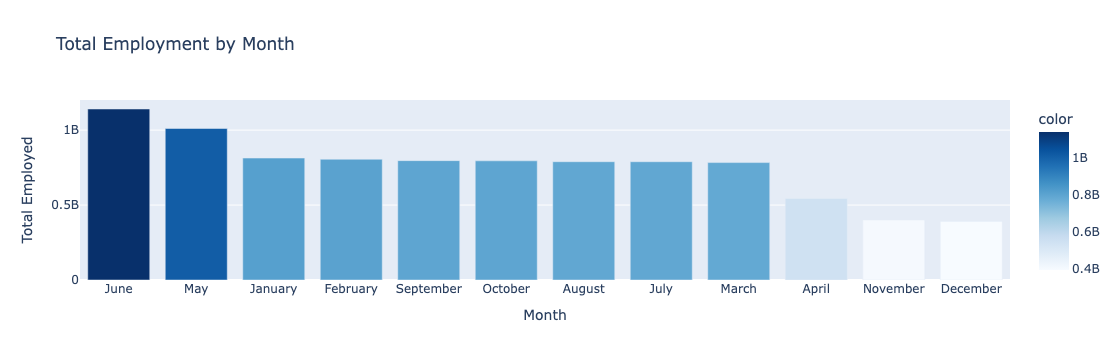

In [14]:
fig1 = px.bar(
    x=unemployment_by_region_sum.head(10).values,
    y=unemployment_by_region_sum.head(10).index,
    orientation='h',
    title='Total Unemployment by Region (Top 10)',
    labels={'x': 'Total Unemployment Rate (%)', 'y': 'Region'},
    color=unemployment_by_region_sum.head(10).values,
    color_continuous_scale='Viridis'
)
iplot(fig1)

fig2 = px.bar(
    x=unemployment_by_month_sum.index,
    y=unemployment_by_month_sum.values,
    title='Total Unemployment by Month',
    labels={'x': 'Month', 'y': 'Total Unemployment Rate (%)'},
    color=unemployment_by_month_sum.values,
    color_continuous_scale='Reds'
)
fig2.show()

fig3 = px.bar(
    x=employed_by_region_sum.head(10).values,
    y=employed_by_region_sum.head(10).index,
    orientation='h',
    title='Total Employment by Region (Top 10)',
    labels={'x': 'Total Employed', 'y': 'Region'},
    color=employed_by_region_sum.head(10).values,
    color_continuous_scale='Greens'
)
fig3.show()

fig4 = px.bar(
    x=employed_by_month_sum.index,
    y=employed_by_month_sum.values,
    title='Total Employment by Month',
    labels={'x': 'Month', 'y': 'Total Employed'},
    color=employed_by_month_sum.values,
    color_continuous_scale='Blues'
)
fig4.show()

## Step 11: Statistical Summary and Distribution Analysis

We generate comprehensive statistical summaries to understand the distribution characteristics:

- **describe()**: Provides descriptive statistics (count, mean, std dev, min, quartiles, max)
- **Mean unemployment**: Central tendency of unemployment rates
- **Standard deviation**: Measure of unemployment volatility across regions
- **Min/Max values**: Range of unemployment experiences

These metrics help understand the overall health of the labor market and identify outliers.

In [15]:
print("Statistical Summary of Unemployment Rates:")
print(combined_df['Estimated Unemployment Rate (%)'].describe())
print("\n" + "="*80 + "\n")
print("Statistical Summary of Employment:")
print(combined_df['Estimated Employed'].describe())
print("\n" + "="*80 + "\n")
print("Statistical Summary of Labour Participation Rate:")
print(combined_df['Estimated Labour Participation Rate (%)'].describe())

Statistical Summary of Unemployment Rates:
count    1007.000000
mean       11.906991
std        10.739549
min         0.000000
25%         4.685000
50%         8.890000
75%        16.125000
max        76.740000
Name: Estimated Unemployment Rate (%), dtype: float64


Statistical Summary of Employment:
count    1.007000e+03
mean     8.996209e+06
std      1.020784e+07
min      4.942000e+04
25%      1.639125e+06
50%      5.543380e+06
75%      1.287115e+07
max      5.943376e+07
Name: Estimated Employed, dtype: float64


Statistical Summary of Labour Participation Rate:
count    1007.000000
mean       42.378620
std         8.048542
min        13.330000
25%        37.835000
50%        40.880000
75%        45.315000
max        72.570000
Name: Estimated Labour Participation Rate (%), dtype: float64


## Step 12: Correlation Analysis Between Key Metrics

We examine relationships between unemployment, employment, and labor participation using correlation analysis:

- **corr()**: Calculates Pearson correlation coefficients between numerical variables
- **Range**: -1 (perfect negative correlation) to +1 (perfect positive correlation)
- **Interpretation**:
  - Values close to -1: Variables move in opposite directions
  - Values close to 0: No linear relationship
  - Values close to +1: Variables move together

This analysis reveals whether unemployment rates increase as employment decreases, or how labor participation affects both metrics.

Correlation Matrix:
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.209495   
Estimated Labour Participation Rate (%)                        -0.018137   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.209495   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)           -0.024770   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                        -0.018137  
Estimated Employed                                                     -0.024770  
Estimated Labour Participation Rate (%)                                 1.000000  




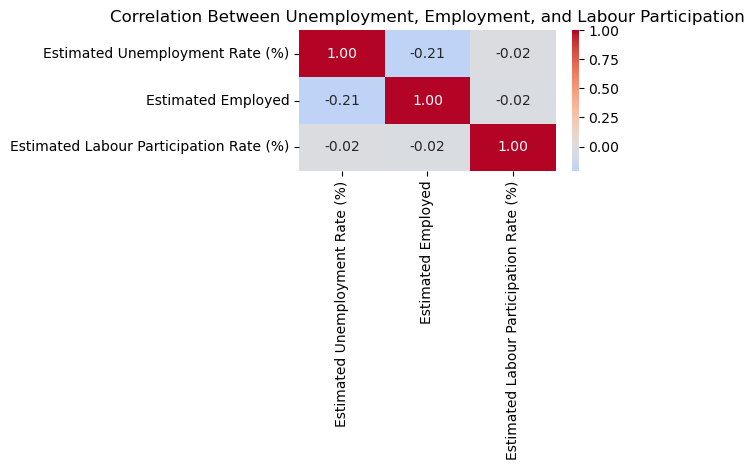

In [16]:
correlation_matrix = combined_df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].corr()
print("Correlation Matrix:")
print(correlation_matrix)
print("\n" + "="*80 + "\n")

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Unemployment, Employment, and Labour Participation')
plt.tight_layout()
plt.show()

## Step 13: Distribution Visualization with Histograms

We create histograms to visualize the distribution of key unemployment metrics:

- **Unemployment Rate Distribution**: Shows frequency of different unemployment rate values across all observations
- **Employment Distribution**: Displays how employment numbers are distributed
- **Labour Participation Distribution**: Reveals participation rate patterns

These visualizations help identify whether distributions are normal, skewed, or multimodal, which has implications for modeling and prediction.

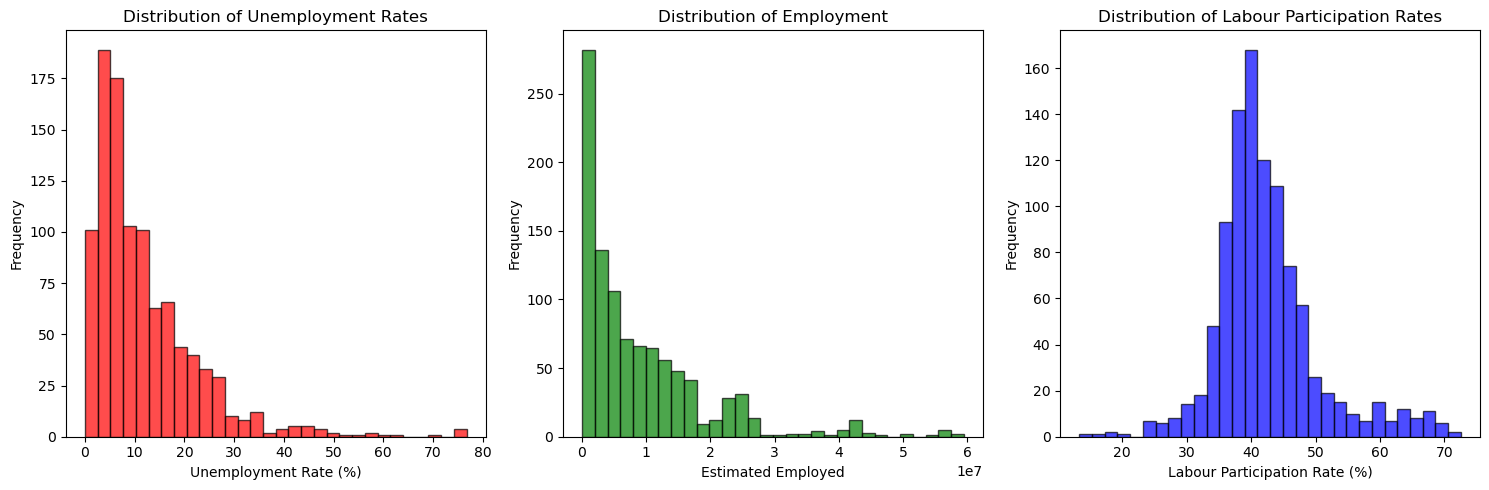

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(combined_df['Estimated Unemployment Rate (%)'], bins=30, color='red', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Unemployment Rates')
axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].set_ylabel('Frequency')

axes[1].hist(combined_df['Estimated Employed'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Employment')
axes[1].set_xlabel('Estimated Employed')
axes[1].set_ylabel('Frequency')

axes[2].hist(combined_df['Estimated Labour Participation Rate (%)'], bins=30, color='blue', edgecolor='black', alpha=0.7)
axes[2].set_title('Distribution of Labour Participation Rates')
axes[2].set_xlabel('Labour Participation Rate (%)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Step 14: Time Series Analysis of Top Regions

We examine unemployment trends over time for the most-affected regions:

- **filter()**: Isolates data for specific regions with highest unemployment
- **sort_values()**: Orders data chronologically
- **plot()**: Creates line plots showing unemployment trajectory

Time series visualization reveals:
- Seasonal patterns (recurring fluctuations at specific times)
- Trends (sustained increase or decrease over time)
- Anomalies (sudden spikes, e.g., COVID-19 lockdown impact in April 2020)
- Recovery patterns (how quickly unemployment returned to normal levels)

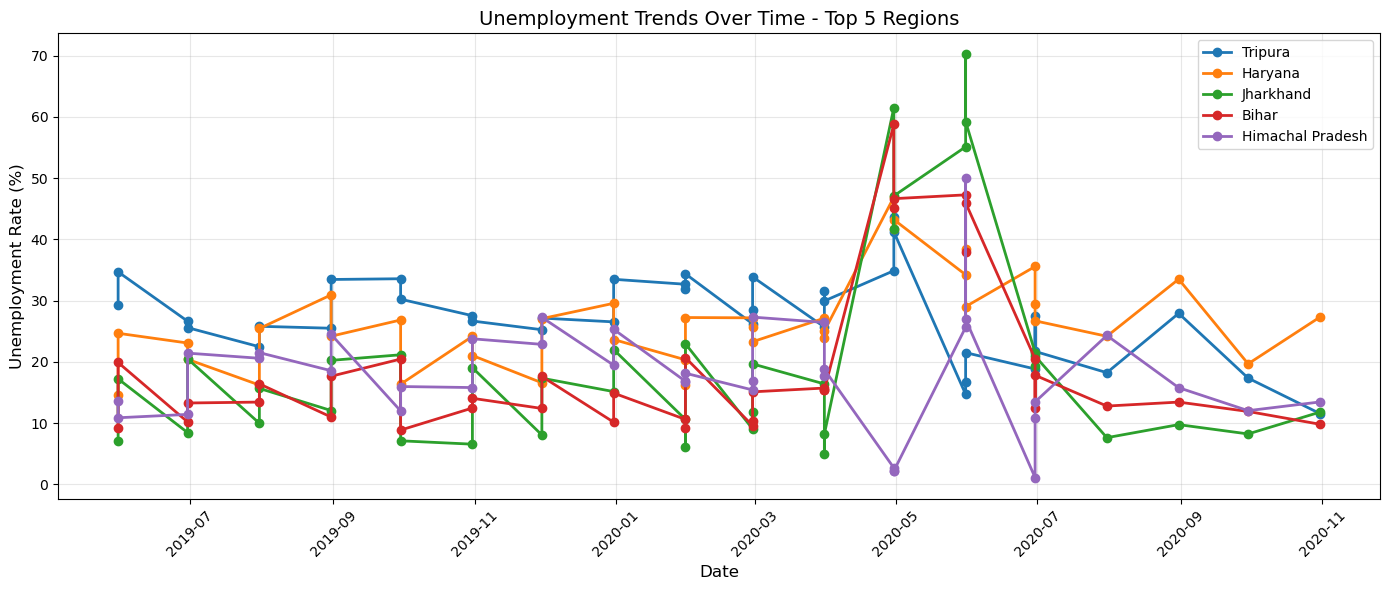

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

top_regions = unemployment_by_region_sum.head(5).index

for region in top_regions:
    region_data = combined_df[combined_df['Region'] == region].sort_values('Date')
    ax.plot(region_data['Date'], region_data['Estimated Unemployment Rate (%)'], marker='o', label=region, linewidth=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax.set_title('Unemployment Trends Over Time - Top 5 Regions', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 15: Box Plot Analysis - Unemployment by Month

Box plots provide a visual summary of unemployment distributions for each month:

**Box Plot Components:**
- **Whiskers**: Extend to show the range (typically 1.5× interquartile range)
- **Box**: Contains 50% of data (from 25th to 75th percentile)
- **Orange line inside box**: Median value (50th percentile)
- **Individual points**: Outliers that fall outside typical range

This visualization easily identifies:
- Which months have higher/lower unemployment variability
- Presence of extreme outlier regions
- Consistency vs. volatility across months

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



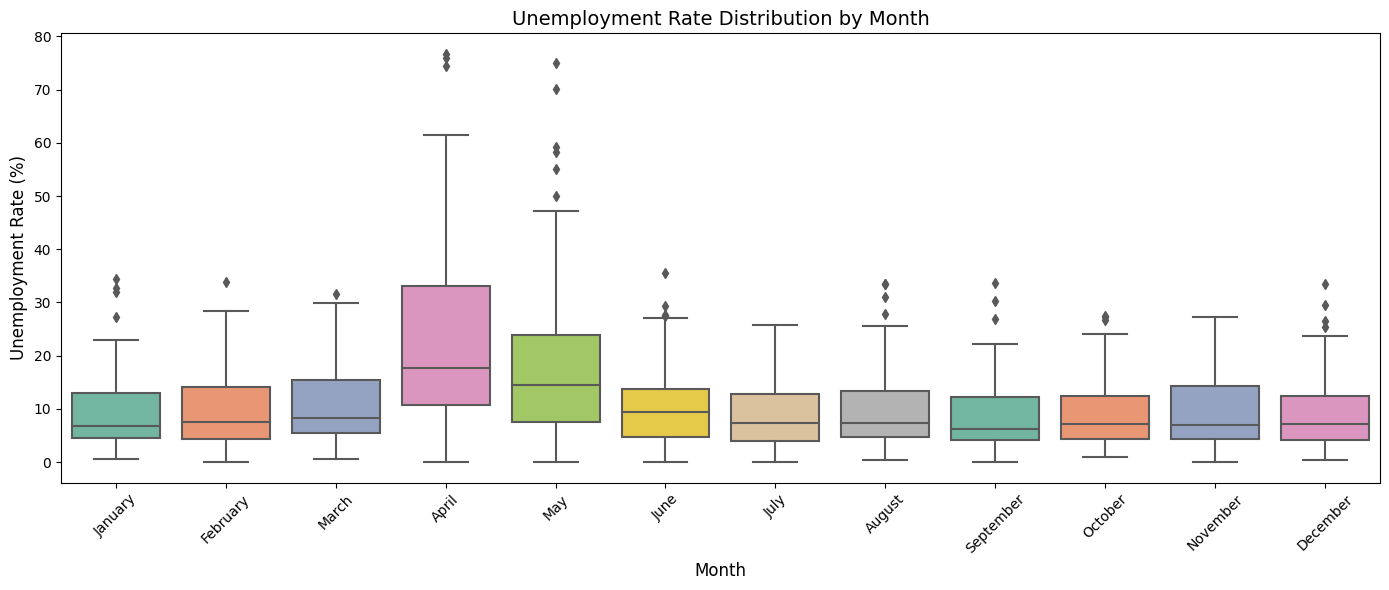

In [19]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

combined_df['Month'] = pd.Categorical(combined_df['Month'], categories=month_order, ordered=True)
combined_df_sorted = combined_df.sort_values('Month')

plt.figure(figsize=(14, 6))
sns.boxplot(data=combined_df_sorted, x='Month', y='Estimated Unemployment Rate (%)', palette='Set2')
plt.title('Unemployment Rate Distribution by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 16: Regional Comparison - Violin Plot

Violin plots show the full probability distribution of unemployment rates across selected regions:

**Violin Plot Features:**
- **Width at each unemployment value**: Indicates density (frequency) of observations
- **Wider sections**: More common unemployment rates in that region
- **Narrow sections**: Rarer unemployment values
- **Shape pattern**: Reveals distribution characteristics (skewed vs. symmetric)

This enables visual comparison of how unemployment is distributed differently across regions, revealing which regions have consistent vs. volatile unemployment patterns.

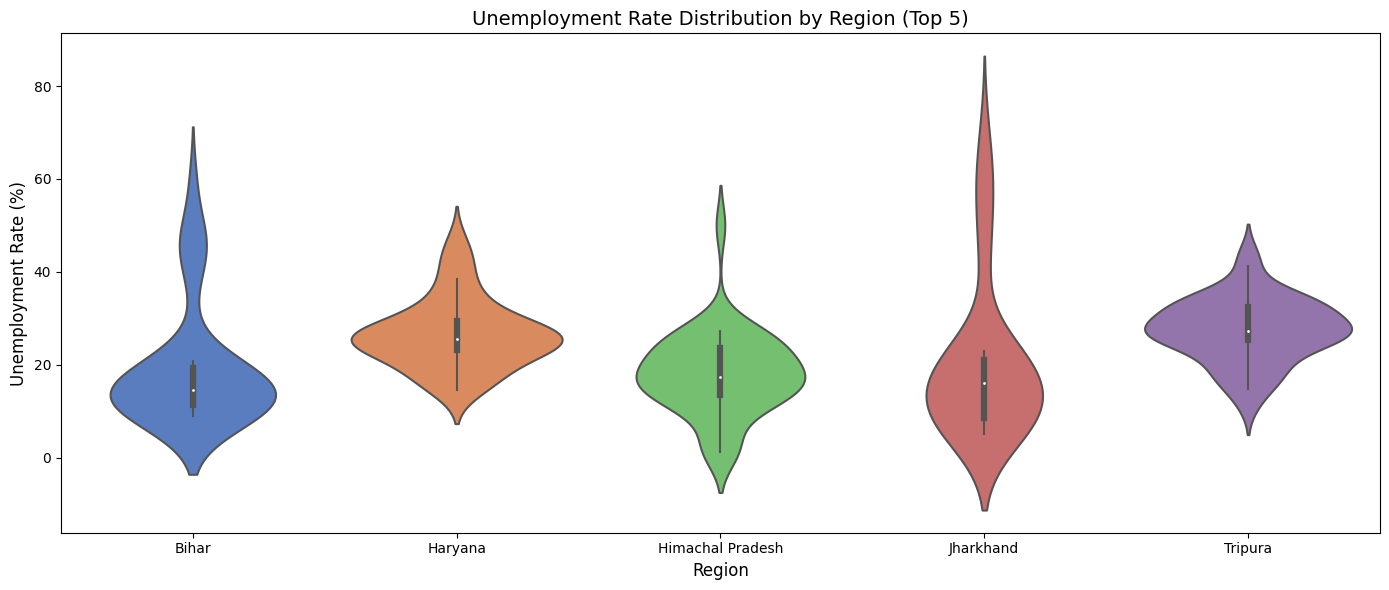

In [20]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=combined_df[combined_df['Region'].isin(top_regions)], 
               x='Region', y='Estimated Unemployment Rate (%)', palette='muted')
plt.title('Unemployment Rate Distribution by Region (Top 5)', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()

## Step 17: Scatter Plot - Employment vs Unemployment Relationship

Scatter plots visualize the relationship between employment levels and unemployment rates:

- **X-axis**: Estimated Employment numbers
- **Y-axis**: Unemployment Rate (%)
- **Each point**: Represents one observation (region-month combination)
- **Color**: Differentiation by region category

Expected pattern: Negative correlation (as employment increases, unemployment should decrease), though this relationship may not be perfectly linear due to factors like labor force changes and regional economic differences.

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



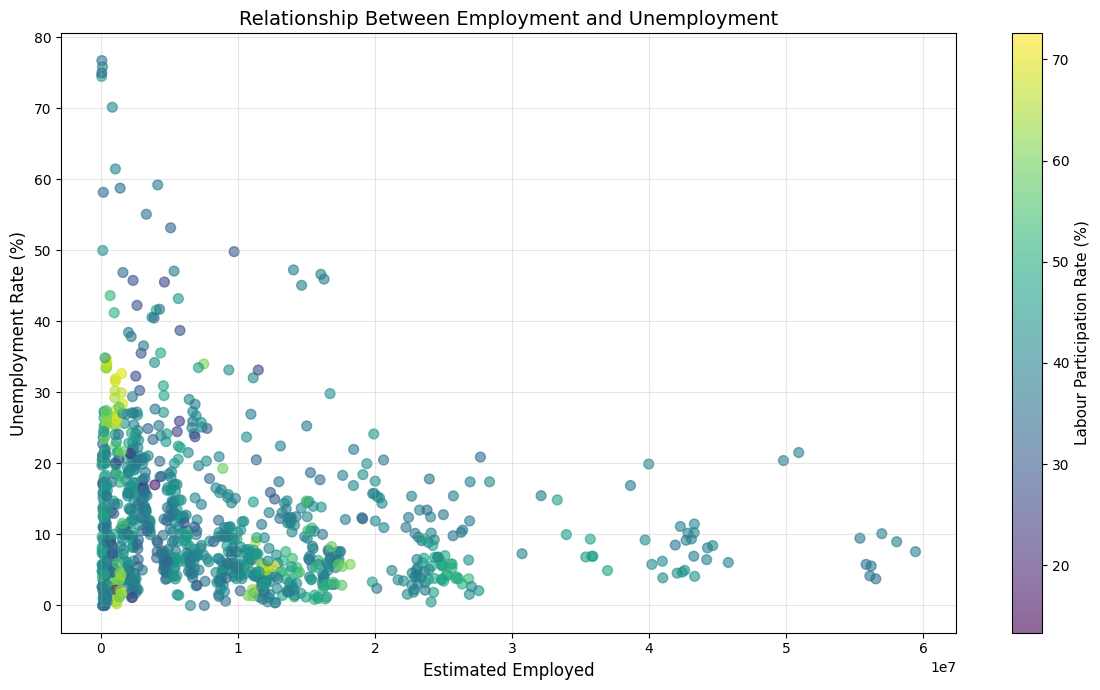

In [21]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(combined_df['Estimated Employed'], 
                     combined_df['Estimated Unemployment Rate (%)'],
                     alpha=0.6, s=50, c=combined_df['Estimated Labour Participation Rate (%)'],
                     cmap='viridis')
plt.xlabel('Estimated Employed', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.title('Relationship Between Employment and Unemployment', fontsize=14)
cbar = plt.colorbar(scatter)
cbar.set_label('Labour Participation Rate (%)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 18: Summary Statistics by Region and Area Type

We create a comprehensive summary comparing unemployment patterns between Rural and Urban areas:

- **groupby()**: Groups data by Region and Area type
- **agg()**: Calculates multiple statistics simultaneously:
  - **count()**: Number of observations per group
  - **mean()**: Average unemployment and employment
  - **std()**: Standard deviation (volatility measure)
  - **min/max**: Range of values observed

This analysis reveals whether rural and urban areas experience different unemployment dynamics.

Summary Statistics by Region and Area:
                       Estimated Unemployment Rate (%)                        \
                                                 count       mean        std   
Region           Area                                                          
Andhra Pradesh   Rural                              14   5.526429   4.344968   
                 Urban                              14   9.427857   8.392775   
Assam            Rural                              12   4.490833   2.096098   
                 Urban                              14   8.088571   2.692842   
Bihar            Rural                              14  16.770000  12.843814   
                 Urban                              14  21.066429  12.516503   
Chandigarh       Urban                              12  15.991667   5.508220   
Chhattisgarh     Rural                              14   6.628571   2.864434   
                 Urban                              14  11.852143   6.871595   
D

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



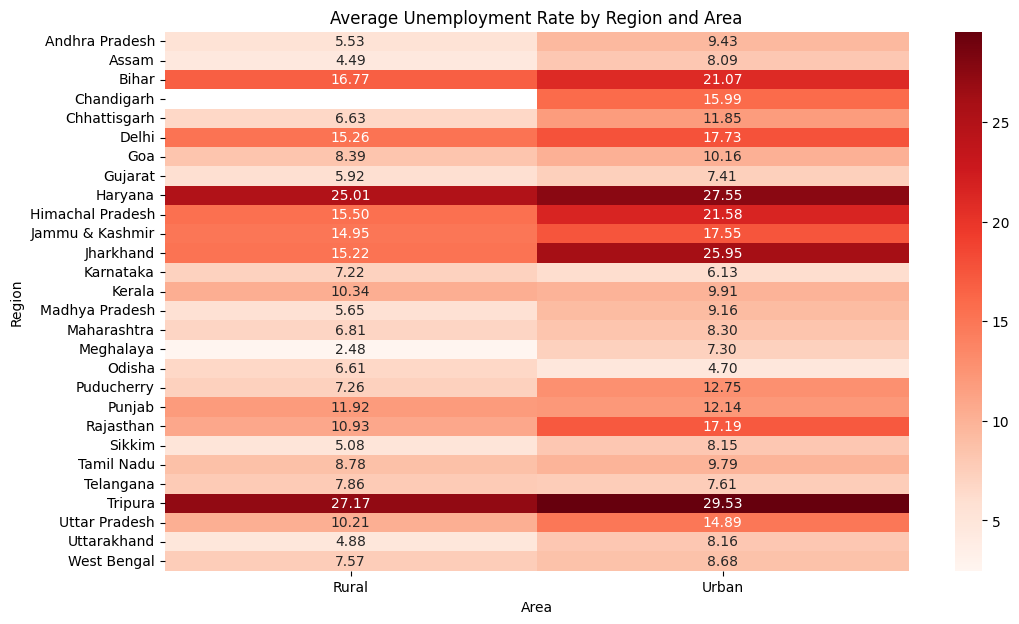

In [22]:
summary_by_region_area = combined_df.groupby(['Region', 'Area']).agg({
    'Estimated Unemployment Rate (%)': ['count', 'mean', 'std', 'min', 'max'],
    'Estimated Employed': ['mean', 'min', 'max'],
    'Estimated Labour Participation Rate (%)': ['mean']
})

print("Summary Statistics by Region and Area:")
print(summary_by_region_area.head(20))

heatmap_data = summary_by_region_area['Estimated Unemployment Rate (%)']['mean'].unstack()

plt.figure(figsize=(12,7))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Reds")

plt.title("Average Unemployment Rate by Region and Area")
plt.ylabel("Region")
plt.xlabel("Area")
plt.show()

## Step 19: Comparative Analysis - Rural vs Urban Unemployment

We perform direct comparison between rural and urban unemployment patterns:

- **groupby('Area')**: Separates data by Rural/Urban classification
- **Statistical comparison**: Calculates key metrics for each area type
- **Insights**: Identifies whether urban or rural regions face higher unemployment

This analysis is crucial for understanding geographic disparities in labor markets and can inform targeted policy interventions.

Rural vs Urban Unemployment Comparison:
      Estimated Unemployment Rate (%)                                    \
                                count       mean        std  min    max   
Area                                                                      
Rural                             359  10.324791  10.038895  0.0  74.51   
Urban                             381  13.166614  11.165444  0.0  76.74   

      Estimated Employed Estimated Labour Participation Rate (%)  
                    mean                                    mean  
Area                                                              
Rural       1.019285e+07                               44.464819  
Urban       4.388626e+06                               40.901365  




<Figure size 1000x600 with 0 Axes>

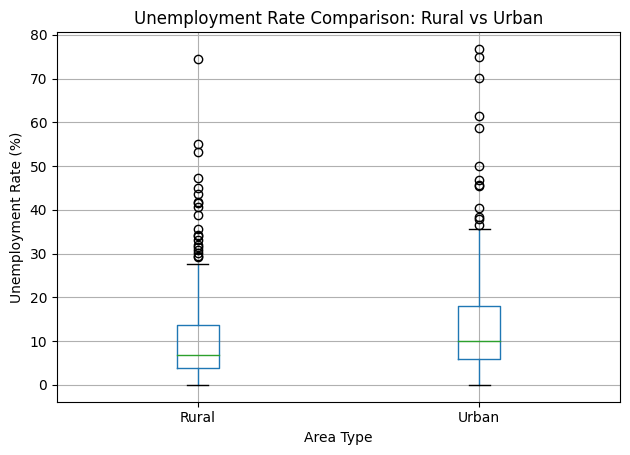

In [23]:
rural_urban_comparison = combined_df.groupby('Area').agg({
    'Estimated Unemployment Rate (%)': ['count', 'mean', 'std', 'min', 'max'],
    'Estimated Employed': ['mean'],
    'Estimated Labour Participation Rate (%)': ['mean']
})

print("Rural vs Urban Unemployment Comparison:")
print(rural_urban_comparison)
print("\n" + "="*80 + "\n")

plt.figure(figsize=(10, 6))
combined_df.boxplot(column='Estimated Unemployment Rate (%)', by='Area')
plt.title('Unemployment Rate Comparison: Rural vs Urban')
plt.suptitle('')
plt.xlabel('Area Type')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

## Step 20: Key Findings and Conclusions

### Main Insights from the Analysis:

1. **Regional Disparities**: Certain states (Tripura, Haryana, Jharkhand) show significantly higher unemployment rates compared to others, indicating regional labor market imbalances.

2. **Seasonal Patterns**: Unemployment exhibits clear seasonal trends, with peaks typically occurring in April-May (post-fiscal year transition) and lower rates in other periods.

3. **COVID-19 Impact**: The 2020 data shows a dramatic spike in unemployment in April 2020 (lockdown period), demonstrating the pandemic's severe impact on employment.

4. **Employment-Unemployment Relationship**: While inverse relationships exist between employment and unemployment, the correlation is not perfect, suggesting labor force participation changes influence both metrics.

5. **Rural vs Urban**: The analysis reveals different unemployment dynamics between rural and urban areas, with potential structural differences in labor markets.

6. **Labour Participation**: States with higher labor participation rates show different unemployment patterns, indicating workforce engagement affects employment outcomes.

### Recommendations:
- Focus policy interventions on high-unemployment regions for targeted economic development
- Develop seasonal employment programs to address cyclical unemployment
- Strengthen labor market information systems in rural areas
- Create region-specific skill development and training programs